Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            0.9998     98.9%      2.2%    1.0187
  2            0.9997     99.4%      2.1%    1.1239
  3            0.9995     99.2%      2.8%    0.6576
  4            0.9992     98.2%      4.3%    0.0940
  5            0.9995     97.8%      3.7%    0.0333
  6            0.7181     95.8%     73.7%    0.0065
Global FF coverage: 99.2%   FB correction: 2.2%
Global correlation FF↔tot: 0.9998


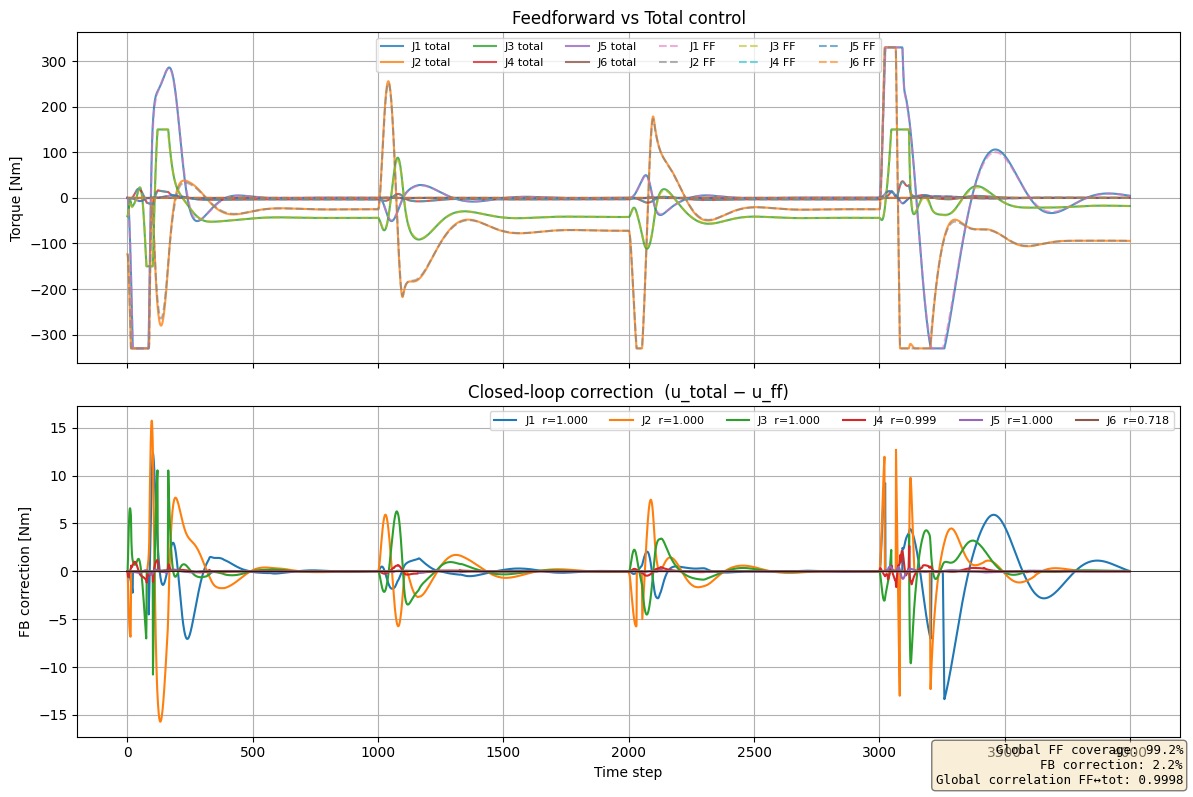

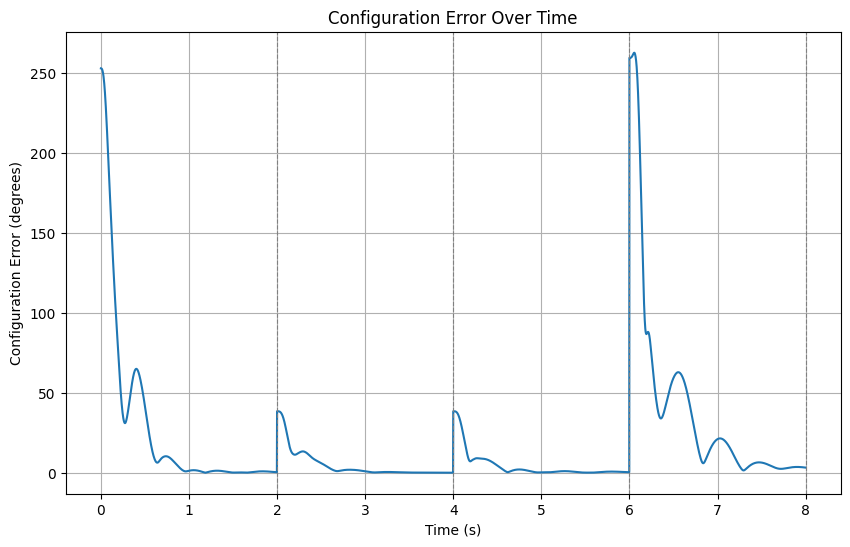

KeyboardInterrupt: 

In [ ]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox, Trajectories
import numpy as np
import time

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_6dof

controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
start_time = time.time()
for i in range(len(path) - 1):
    start = np.concatenate([path[i], v_start])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                            x_goal=target, 
                                            T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                            alpha=.8,
                                            interpolation="quintic", # linear, trapezoidal, cubic, quintic
                                            option="pd")
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]
end_time = time.time()
controller_time = end_time - start_time
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
robot_mj_model.plot_feedback_part(us_real, us)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.reset()

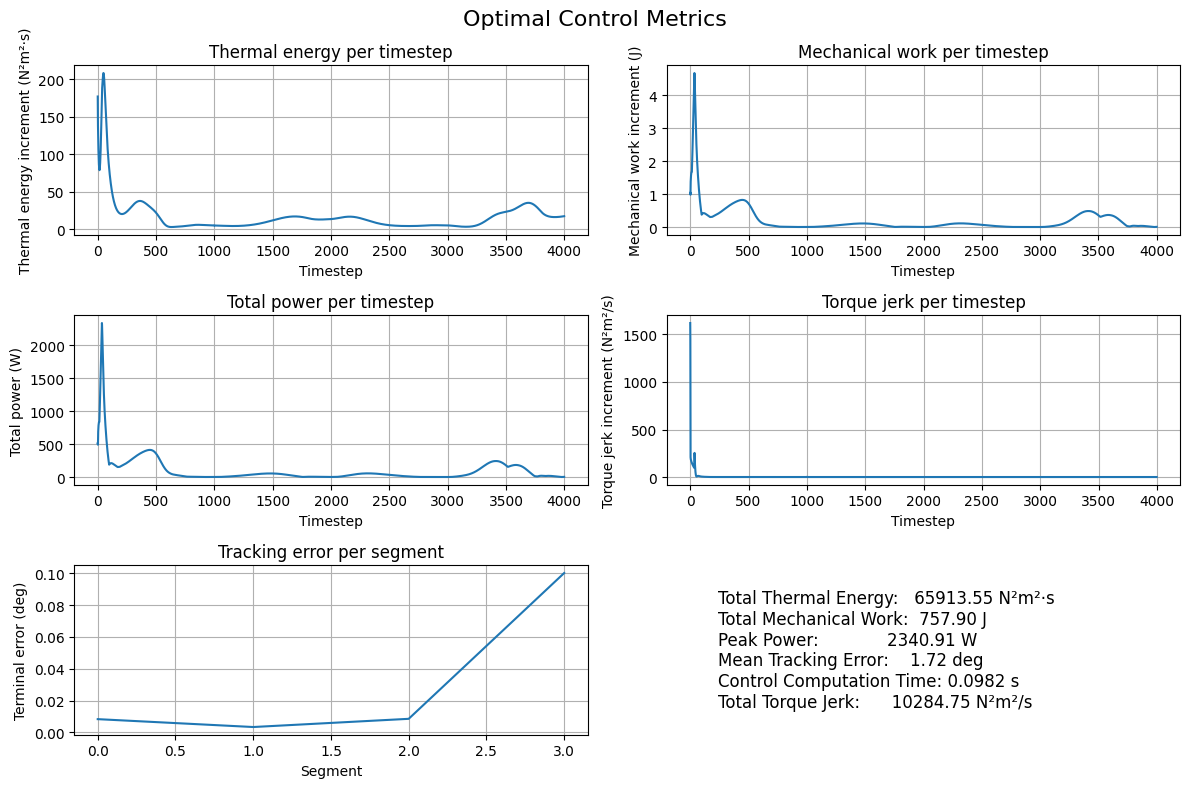

In [4]:
from optimal.metrics import plot_metrics

plot_metrics(us_real, xs_real, DT, path[1:], [1000]*(len(path)-1), controller_time)

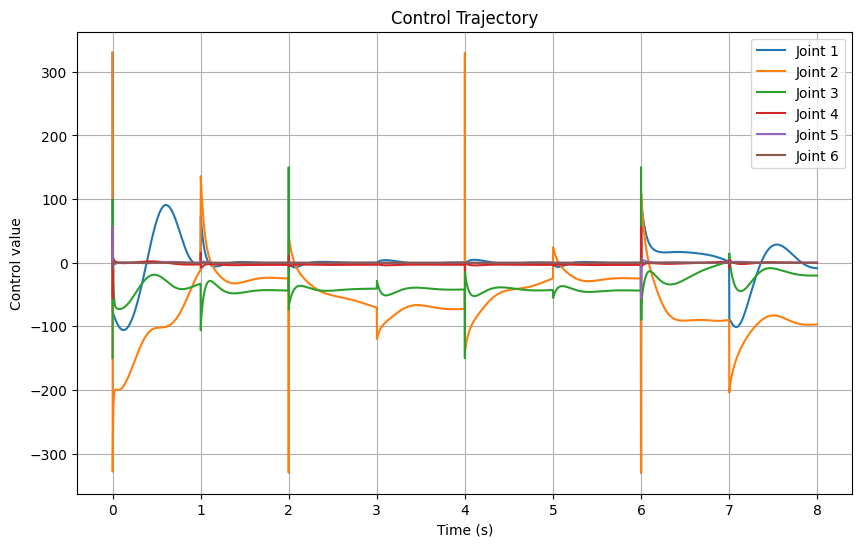

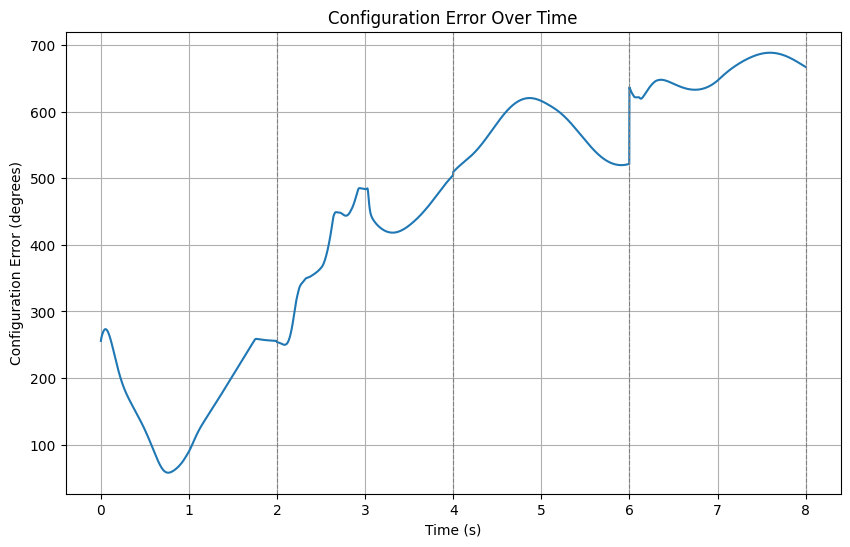

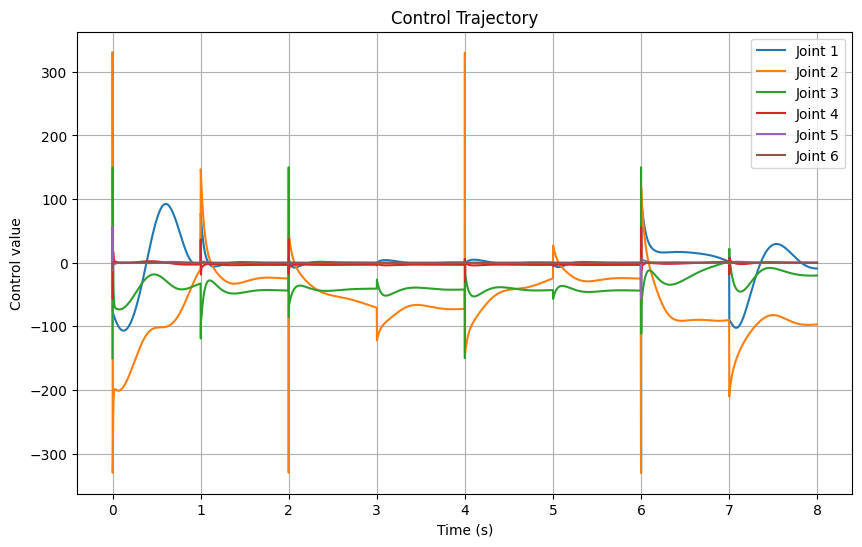

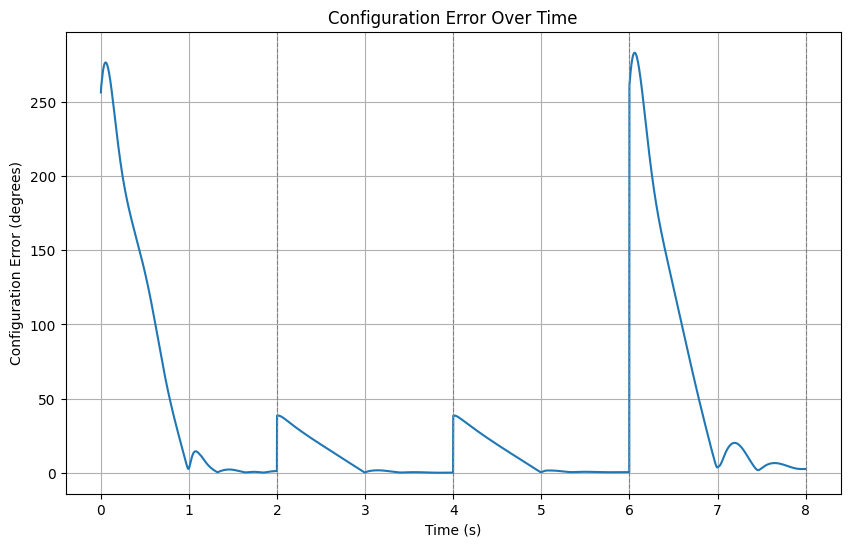

In [6]:
# Visualize Path computed by Mujoco - Open loop control with ideal model
robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Open loop control without feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Closed loop control with feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)

